# Uebung 7: Data Cleaning - Airbnb Berlin

**DataPy - WiSe25/26 - Woche 7**

## Lernziele

- Datensaetze systematisch inspizieren
- Datenqualitaetsprobleme identifizieren
- Data-Cleaning-Pipeline entwickeln
- Bereinigte Datensaetze speichern

## Datensatz
Inside Airbnb - Berlin Listings

## Teil 1: Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

pd.set_option('display.max_columns', None)
print("Bibliotheken importiert")

Bibliotheken importiert


In [2]:
df = pd.read_csv('listings.csv')
df_clean = df.copy()
print(f"Geladen: {df.shape[0]} Zeilen, {df.shape[1]} Spalten")

Geladen: 14274 Zeilen, 79 Spalten


## Teil 2: Inspektion

In [3]:
important = ['id', 'name', 'neighbourhood_cleansed', 'property_type',
             'room_type', 'accommodates', 'bedrooms', 'price',
             'number_of_reviews', 'review_scores_rating']

print("Shape:", df.shape)
print("\nWichtige Spalten:")
display(df[important].head())
print("\nPreis-Beispiele:")
print(df['price'].head(5))

Shape: (14274, 79)

Wichtige Spalten:


,id,name,neighbourhood_cleansed,property_type,room_type,accommodates,bedrooms,price,number_of_reviews,review_scores_rating
0,3176,Fabulous Flat in great Location,Prenzlauer Berg Südwest,Entire rental unit,Entire home/apt,2,1.0,$105.00,150,4.63
1,9991,Geourgeous flat - outstanding views,Prenzlauer Berg Südwest,Entire rental unit,Entire home/apt,7,4.0,$135.00,7,5.00
2,14325,Studio Apartment in Prenzlauer Berg,Prenzlauer Berg Nordwest,Entire rental unit,Entire home/apt,1,0.0,$75.00,26,4.68
3,17904,Beautiful Kreuzberg studio - 3 months minimum,Reuterstraße,Entire rental unit,Entire home/apt,2,0.0,$32.00,298,4.77
4,20858,Designer Loft in Berlin Mitte,Prenzlauer Berg Südwest,Entire loft,Entire home/apt,4,2.0,$202.00,140,4.48



Preis-Beispiele:
0    $105.00
1    $135.00
2     $75.00
3     $32.00
4    $202.00
Name: price, dtype: object


## Teil 3: Fehlende Werte

In [4]:
missing = df_clean[important].isnull().sum()
missing_pct = (missing / len(df_clean)) * 100
missing_df = pd.DataFrame({
    'Spalte': missing.index,
    'Fehlend': missing.values,
    'Prozent': missing_pct.values
})
missing_df = missing_df[missing_df['Fehlend'] > 0]
display(missing_df)

,Spalte,Fehlend,Prozent
6,bedrooms,2024,14.179627
7,price,5010,35.098781
9,review_scores_rating,3314,23.217038


## Teil 4: Preis-Konvertierung

In [5]:
def clean_price(price_str):
    if pd.isna(price_str):
        return np.nan
    cleaned = str(price_str).replace('$', '').replace(',', '')
    try:
        return float(cleaned)
    except:
        return np.nan

df_clean['price_num'] = df_clean['price'].apply(clean_price)
print("Preis konvertiert")
print(df_clean['price_num'].describe())

Preis konvertiert
count     9264.000000
mean       201.240393
std       1656.989769
min          5.000000
25%         70.000000
50%        104.000000
75%        160.000000
max      50000.000000
Name: price_num, dtype: float64


## Teil 5: Duplikate

In [6]:
dups = df_clean.duplicated(subset=['id']).sum()
print(f"Duplikate: {dups}")
df_clean.drop_duplicates(subset=['id'], inplace=True)
print(f"Nach Entfernung: {df_clean.shape[0]} Zeilen")

Duplikate: 0
Nach Entfernung: 14274 Zeilen


## Teil 6: Ausreisser

Preis-Statistiken:
count     9264.000000
mean       201.240393
std       1656.989769
min          5.000000
25%         70.000000
50%        104.000000
75%        160.000000
max      50000.000000
Name: price_num, dtype: float64


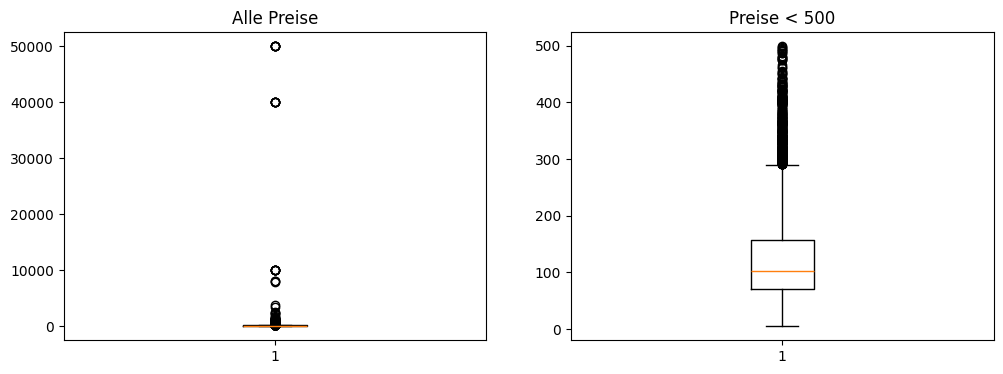

In [7]:
print("Preis-Statistiken:")
print(df_clean['price_num'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df_clean['price_num'].dropna())
axes[0].set_title('Alle Preise')

filtered = df_clean[df_clean['price_num'] < 500]
axes[1].boxplot(filtered['price_num'].dropna())
axes[1].set_title('Preise < 500')
plt.show()

## Teil 7: Feature Engineering

In [8]:
df_clean['price_cat'] = pd.cut(df_clean['price_num'],
                                bins=[0, 50, 100, 200, 10000],
                                labels=['guenstig', 'mittel', 'teuer', 'luxus'])

df_clean['has_reviews'] = df_clean['number_of_reviews'] > 0
print("Features erstellt")

Features erstellt


## Teil 8: Validierung

In [9]:
print("VERGLEICH")
print(f"Original: {df.shape}")
print(f"Bereinigt: {df_clean.shape}")
retention = (df_clean.shape[0]/df.shape[0])*100
print(f"Retention: {retention:.1f}%")

VERGLEICH
Original: (14274, 79)
Bereinigt: (14274, 82)
Retention: 100.0%


## Teil 9: Speichern

In [10]:
export_cols = ['id', 'name', 'neighbourhood_cleansed', 'latitude',
               'longitude', 'property_type', 'room_type', 'accommodates',
               'bedrooms', 'beds', 'price_num', 'number_of_reviews',
               'review_scores_rating', 'price_cat', 'has_reviews']

export_cols = [c for c in export_cols if c in df_clean.columns]

output = 'airbnb_berlin_cleaned.csv'
df_clean[export_cols].to_csv(output, index=False)
print(f"Gespeichert: {output}")
print(f"Zeilen: {df_clean.shape[0]}")
print(f"Spalten: {len(export_cols)}")

Gespeichert: airbnb_berlin_cleaned.csv
Zeilen: 14274
Spalten: 15


## Reflexion

1. Groesste Herausforderungen?
2. Schwierigste Entscheidungen?
3. Erkenntnisse ueber Airbnb Berlin?
4. Zuversicht (1-10)?
5. Fragen fuer Woche 8?